In [18]:
import pandas as pd
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()


df = pd.DataFrame(data = diabetes.data, columns = diabetes.feature_names)
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [22]:
data = pd.read_csv('diabetes.csv')
print(data)

data.head()

        id   chol  stab.glu   hdl  ratio      glyhb    location  age  gender  \
0     1000  203.0        82  56.0    3.6   4.310000  Buckingham   46  female   
1     1001  165.0        97  24.0    6.9   4.440000  Buckingham   29  female   
2     1002  228.0        92  37.0    6.2   4.640000  Buckingham   58  female   
3     1003   78.0        93  12.0    6.5   4.630000  Buckingham   67    male   
4     1005  249.0        90  28.0    8.9   7.720000  Buckingham   64    male   
..     ...    ...       ...   ...    ...        ...         ...  ...     ...   
398  41506  296.0       369  46.0    6.4  16.110001      Louisa   53    male   
399  41507  284.0        89  54.0    5.3   4.390000      Louisa   51  female   
400  41510  194.0       269  38.0    5.1  13.630000      Louisa   29  female   
401  41752  199.0        76  52.0    3.8   4.490000      Louisa   41  female   
402  41756  159.0        88  79.0    2.0        NaN      Louisa   68  female   

     height  weight   frame  bp.1s  bp.

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [29]:
data.dtypes
data.isnull().sum()

id            0
chol          1
stab.glu      0
hdl           1
ratio         1
glyhb        13
location      0
age           0
gender        0
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64

In [67]:
import numpy as np

# ===== 1. Initial Inspection =====
print("=== Initial Missing Values ===")
print(df.isnull().sum().sort_values(ascending=False))

# ===== 2. Cleaning Strategy =====
# Strategy for each column based on data importance and missingness
cleaning_plan = {
    # Columns to drop if missing (critical ID/outcome variables)
    'glyhb': 'drop',  # Our primary outcome measure
    'id': 'drop',     # Unique identifier
    
    # Columns to fill with median (numerical variables)
    'chol': 'fill_median',
    'hdl': 'fill_median',
    'ratio': 'fill_median',
    'age': 'fill_median',
    'height': 'fill_median',
    'weight': 'fill_median',
    'waist': 'fill_median',
    'hip': 'fill_median',
    
    # Columns to fill with mode (categorical variables)
    'location': 'fill_mode',
    'gender': 'fill_mode',
    'frame': 'fill_mode',
    
    # Columns to drop (high missingness or less important)
    'bp.2s': 'drop',
    'bp.2d': 'drop',
    'time.ppn': 'drop'  # Time post-prandial often incomplete
}

# ===== 3. Execute Cleaning =====
clean_df = df.copy()

for col, action in cleaning_plan.items():
    if col not in df.columns:
        continue
        
    if action == 'drop':
        clean_df = clean_df.dropna(subset=[col])
    elif action == 'fill_median':
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())
    elif action == 'fill_mode':
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

# ===== 4. Final Quality Check =====
print("\n=== Remaining Missing Values ===")
print(clean_df.isnull().sum().sort_values(ascending=False))

# ===== 5. Save Cleaned Data =====
clean_df.to_csv('cleaned_diabetes.csv', index=False)
print("\nCleaned dataset saved to 'cleaned_diabetes.csv'")

# ===== 6. Verification =====
print("\n=== Dataset Shape ===")
print(f"Original: {df.shape} | Cleaned: {clean_df.shape}")
print(f"Rows removed: {len(df) - len(clean_df)} ({((len(df)-len(clean_df))/len(df))*100:.1f}%)")

=== Initial Missing Values ===
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

=== Remaining Missing Values ===
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Cleaned dataset saved to 'cleaned_diabetes.csv'

=== Dataset Shape ===
Original: (442, 10) | Cleaned: (442, 10)
Rows removed: 0 (0.0%)


In [36]:
data.describe()

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


In [38]:
numeric_column = data.select_dtypes(include = 'number').columns 
data.groupby('age')[numeric_column].describe()

id                                                                    \
    count          mean           std      min       25%      50%       75%   
age                                                                           
19    2.0  11306.500000   9169.053632   4823.0   8064.75  11306.5  14548.25   
20   10.0  17641.300000  14153.922551   1041.0   6007.00  16902.5  20346.75   
21    6.0  15341.500000   6719.671026   4783.0  11316.75  17779.0  20350.25   
22    5.0  10050.200000   9902.837306   1317.0   2787.00   4506.0  20318.00   
23    7.0  13878.714286   6363.693417   3250.0  10006.00  15515.0  19047.50   
..    ...           ...           ...      ...       ...      ...       ...   
83    1.0   4803.000000           NaN   4803.0   4803.00   4803.0   4803.00   
84    1.0  40784.000000           NaN  40784.0  40784.00  40784.0  40784.00   
89    1.0  41503.000000           NaN  41503.0  41503.00  41503.0  41503.00   
91    1.0   2794.000000           NaN   2794.0   2794.00   2794.0   2794.00   
92    1.0   2770.000000           NaN   2770.0   2770.00   2770.0   2770.00   

              chol              ...   hip       time.ppn              \
         max count        mean  ...   75%   max    count        mean   
age                             ...                                    
19   17790.0   2.0  169.500000  ...  39.5  40.0      2.0  270.000000   
20   40804.0  10.0  186.600000  ...  44.0  58.0     10.0  582.000000   
21   21338.0   6.0  182.333333  ...  43.0  52.0      6.0  281.666667   
22   21323.0   5.0  182.600000  ...  40.0  50.0      5.0  450.000000   
23   20279.0   7.0  187.000000  ...  48.0  50.0      7.0  481.428571   
..       ...   ...         ...  ...   ...   ...      ...         ...   
83    4803.0   1.0  227.000000  ...  40.0  40.0      1.0  300.000000   
84   40784.0   1.0  226.000000  ...  48.0  48.0      1.0  210.000000   
89   41503.0   1.0  301.000000  ...  41.0  41.0      1.0  210.000000   
91    2794.0   1.0  232.000000  ...  38.0  38.0      1.0  120.000000   
92    2770.0   1.0  165.000000  ...  51.0  51.0      1.0  180.000000   

                                                     
            std    min    25%    50%    75%     max  
age                                                  
19    42.426407  240.0  255.0  270.0  285.0   300.0  
20   551.760818   60.0  142.5  330.0  990.0  1440.0  
21   312.692607   10.0  180.0  180.0  225.0   900.0  
22   368.646172  120.0  210.0  240.0  720.0   960.0  
23   331.684015   10.0  240.0  600.0  720.0   840.0  
..          ...    ...    ...    ...    ...     ...  
83          NaN  300.0  300.0  300.0  300.0   300.0  
84          NaN  210.0  210.0  210.0  210.0   210.0  
89          NaN  210.0  210.0  210.0  210.0   210.0  
91          NaN  120.0  120.0  120.0  120.0   120.0  
92          NaN  180.0  180.0  180.0  180.0   180.0  

[68 rows x 128 columns]

In [ ]:
# For the answer to this question, please see "Week7-Notes.txt". Thank you!

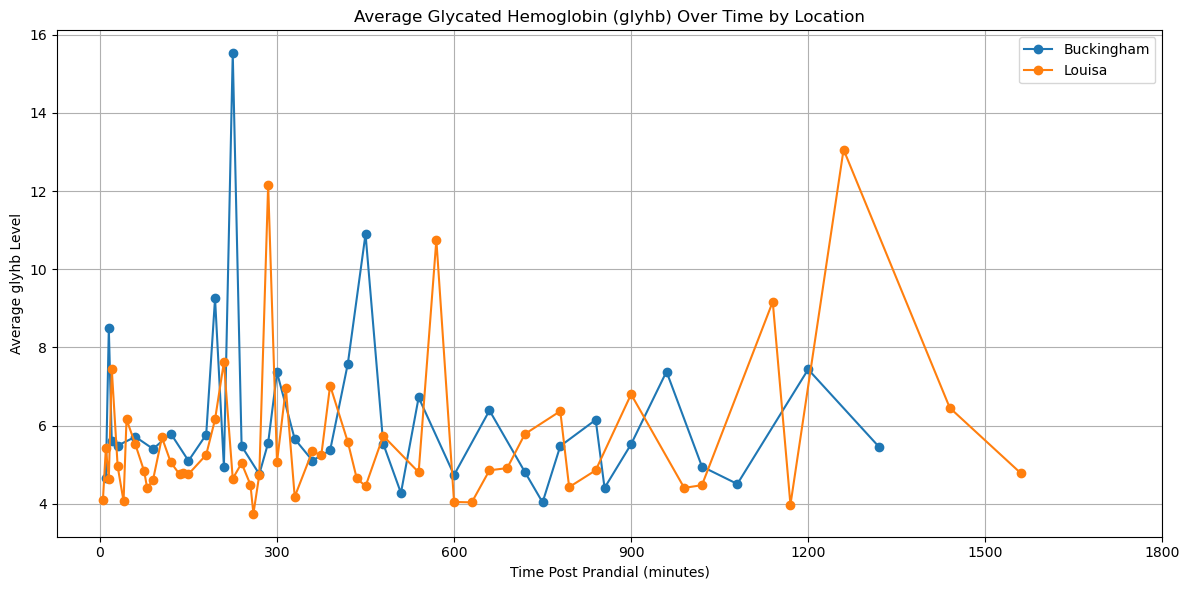

In [53]:
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('diabetes.csv')

# Clean the data - remove rows with missing glyhb or time.ppn values
clean_data = data.dropna(subset=['glyhb', 'time.ppn', 'location'])

# Group by location and time.ppn, then calculate mean glyhb
trend_data = clean_data.groupby(['location', 'time.ppn'])['glyhb'].mean().reset_index()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each location separately
for location in trend_data['location'].unique():
    location_data = trend_data[trend_data['location'] == location]
    plt.plot(location_data['time.ppn'], location_data['glyhb'], 
             label=location, marker='o')

plt.title('Average Glycated Hemoglobin (glyhb) Over Time by Location')
plt.xlabel('Time Post Prandial (minutes)')
plt.ylabel('Average glyhb Level')
plt.legend()
plt.grid(True)

# Improve x-axis ticks (time.ppn is in minutes)
plt.xticks(range(0, int(trend_data['time.ppn'].max())+300, 300))

plt.tight_layout()
plt.show()

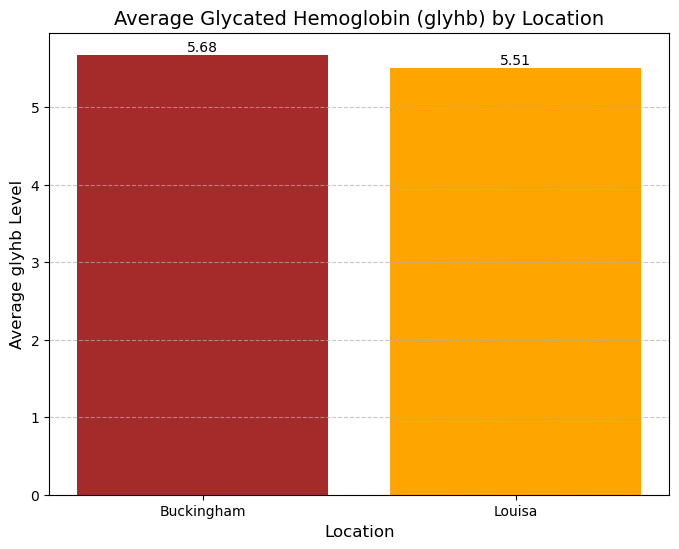

In [59]:
# Load the dataset
data = pd.read_csv('diabetes.csv')

# Filter out missing glyhb values
clean_data = data.dropna(subset=['glyhb', 'location'])

# Calculate average glyhb by location
avg_glyhb = clean_data.groupby('location')['glyhb'].mean().reset_index()

# Create the bar graph
plt.figure(figsize=(8, 6))
bars = plt.bar(avg_glyhb['location'], avg_glyhb['glyhb'], color=['brown', 'orange'])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom')

# Customize the plot
plt.title('Average Glycated Hemoglobin (glyhb) by Location', fontsize=14)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Average glyhb Level', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

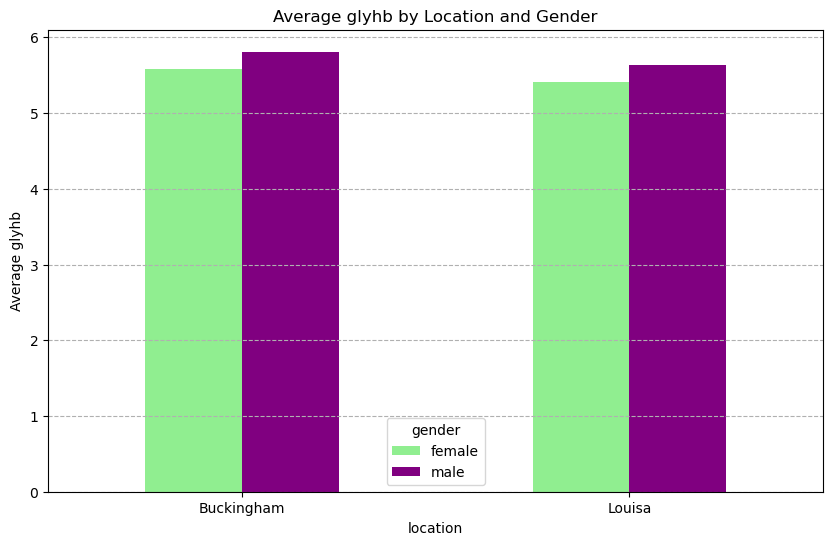

In [58]:
# Group by location and gender
grouped_data = clean_data.groupby(['location', 'gender'])['glyhb'].mean().unstack()

# Plot grouped bars
grouped_data.plot(kind='bar', figsize=(10, 6), color=['lightgreen', 'purple'])
plt.title('Average glyhb by Location and Gender')
plt.ylabel('Average glyhb')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

/tmp/ipykernel_143/452488673.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['age_group'] = pd.cut(clean_data['age'], bins=[0, 30, 50, 100], labels=['<30', '30-50', '50+'])
/tmp/ipykernel_143/452488673.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stacked_data = clean_data.groupby(['location', 'age_group'])['glyhb'].mean().unstack()


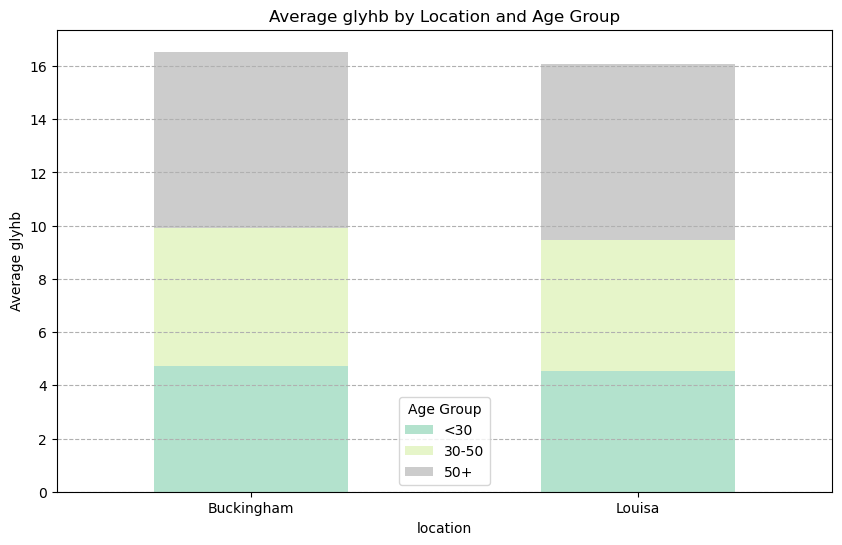

In [56]:
# Create age groups
clean_data['age_group'] = pd.cut(clean_data['age'], bins=[0, 30, 50, 100], labels=['<30', '30-50', '50+'])

# Group by location and age group
stacked_data = clean_data.groupby(['location', 'age_group'])['glyhb'].mean().unstack()

# Plot stacked bars
stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Pastel2')
plt.title('Average glyhb by Location and Age Group')
plt.ylabel('Average glyhb')
plt.xticks(rotation=0)
plt.legend(title='Age Group')
plt.grid(axis='y', linestyle='--')
plt.show()

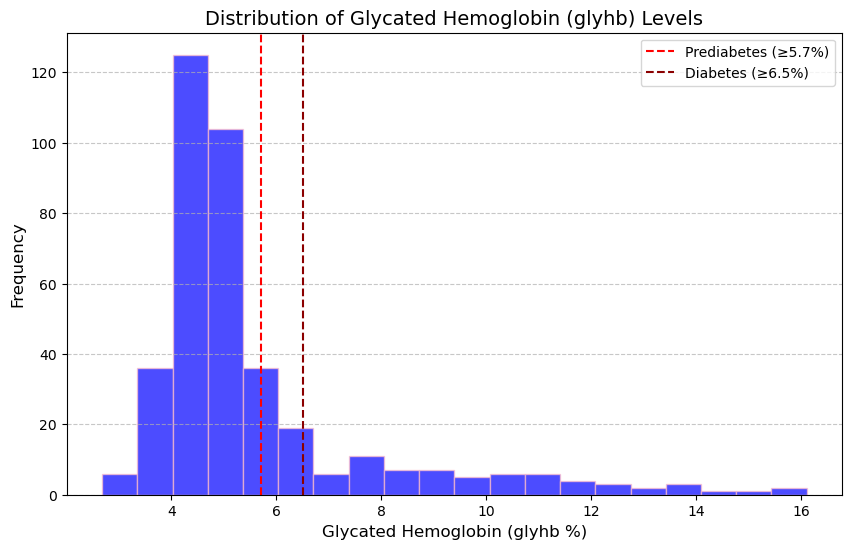

In [60]:
# Clean the data (remove missing glyhb values)
clean_data = data.dropna(subset=['glyhb'])

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(clean_data['glyhb'], bins=20, color='blue', edgecolor='pink', alpha=0.7)

# Add reference lines for diabetes thresholds
plt.axvline(x=5.7, color='red', linestyle='--', label='Prediabetes (≥5.7%)')
plt.axvline(x=6.5, color='darkred', linestyle='--', label='Diabetes (≥6.5%)')

# Customize the plot
plt.title('Distribution of Glycated Hemoglobin (glyhb) Levels', fontsize=14)
plt.xlabel('Glycated Hemoglobin (glyhb %)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

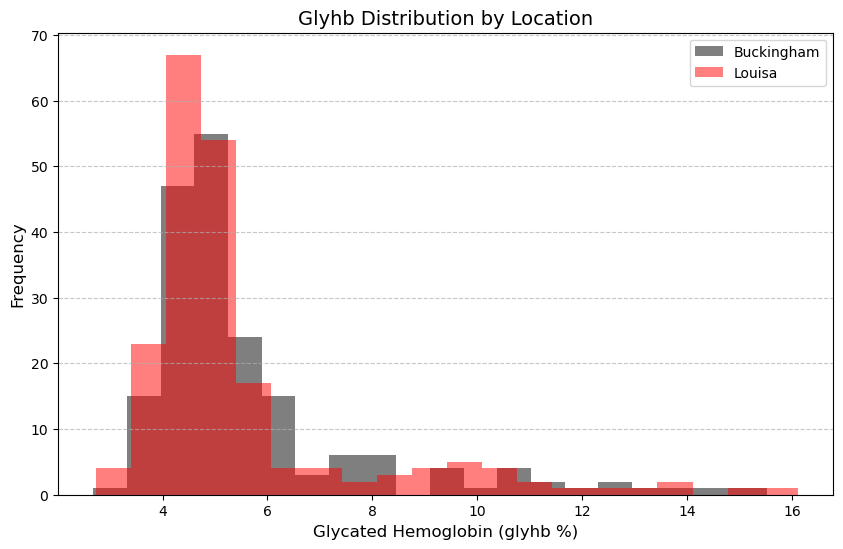

In [62]:
plt.figure(figsize=(10, 6))

# Filter data by location
buckingham = clean_data[clean_data['location'] == 'Buckingham']['glyhb']
louisa = clean_data[clean_data['location'] == 'Louisa']['glyhb']

# Plot overlapping histograms
plt.hist(buckingham, bins=20, color='black', alpha=0.5, label='Buckingham')
plt.hist(louisa, bins=20, color='red', alpha=0.5, label='Louisa')

plt.title('Glyhb Distribution by Location', fontsize=14)
plt.xlabel('Glycated Hemoglobin (glyhb %)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

/tmp/ipykernel_143/2857740183.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['age_group'] = pd.cut(clean_data['age'], bins=[20, 40, 60, 100], labels=['20-40', '40-60', '60+'])


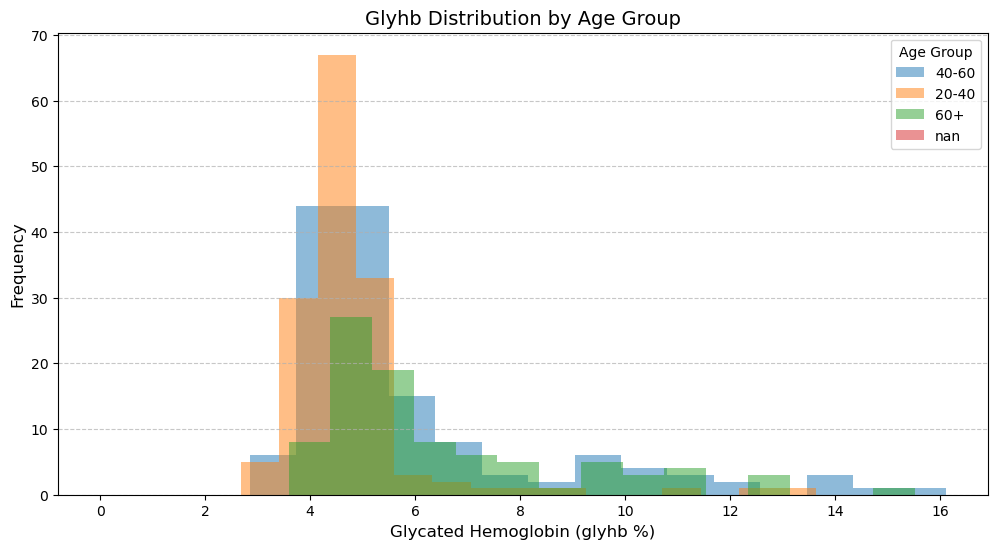

In [63]:
# Create age groups
clean_data['age_group'] = pd.cut(clean_data['age'], bins=[20, 40, 60, 100], labels=['20-40', '40-60', '60+'])

# Plot histograms for each age group
plt.figure(figsize=(12, 6))
for age_group in clean_data['age_group'].unique():
    subset = clean_data[clean_data['age_group'] == age_group]
    plt.hist(subset['glyhb'], bins=15, alpha=0.5, label=age_group)

plt.title('Glyhb Distribution by Age Group', fontsize=14)
plt.xlabel('Glycated Hemoglobin (glyhb %)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title='Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

NameError: name 'np' is not defined

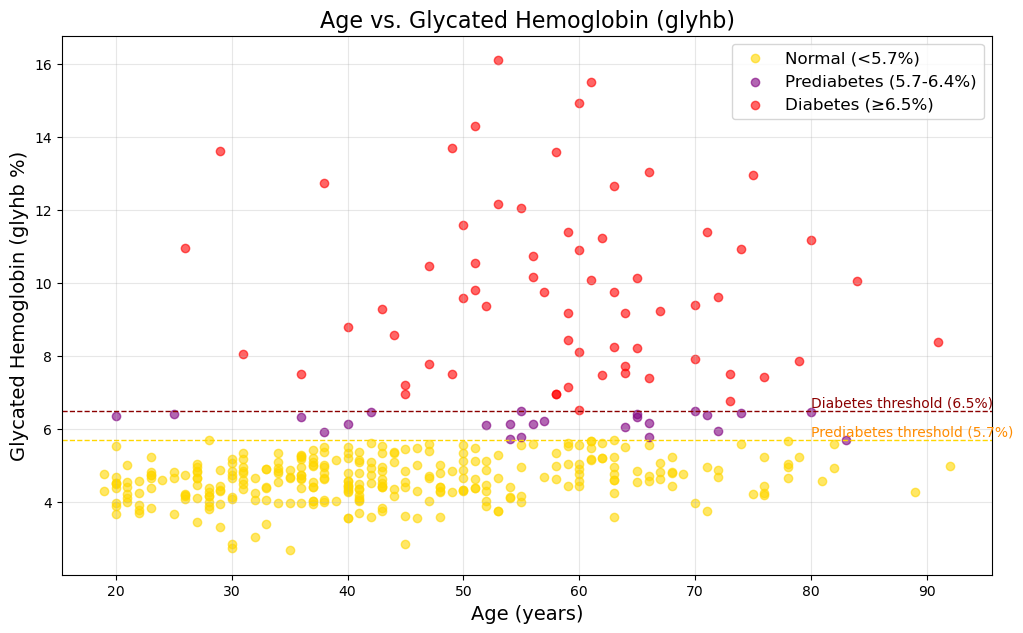

In [64]:
# Clean the data (remove missing age/glyhb values)
clean_data = data.dropna(subset=['age', 'glyhb'])

# Create the scatter plot
plt.figure(figsize=(12, 7))

# Color points based on diabetes thresholds
normal = clean_data[clean_data['glyhb'] < 5.7]
prediabetes = clean_data[(clean_data['glyhb'] >= 5.7) & (clean_data['glyhb'] < 6.5)]
diabetes = clean_data[clean_data['glyhb'] >= 6.5]

plt.scatter(normal['age'], normal['glyhb'], color='gold', alpha=0.6, label='Normal (<5.7%)')
plt.scatter(prediabetes['age'], prediabetes['glyhb'], color='purple', alpha=0.6, label='Prediabetes (5.7-6.4%)')
plt.scatter(diabetes['age'], diabetes['glyhb'], color='red', alpha=0.6, label='Diabetes (≥6.5%)')

# Add reference lines for diabetes thresholds
plt.axhline(y=5.7, color='gold', linestyle='--', linewidth=1)
plt.axhline(y=6.5, color='darkred', linestyle='--', linewidth=1)

# Add text annotations for thresholds
plt.text(80, 5.8, 'Prediabetes threshold (5.7%)', color='darkorange')
plt.text(80, 6.6, 'Diabetes threshold (6.5%)', color='darkred')

# Customize the plot
plt.title('Age vs. Glycated Hemoglobin (glyhb)', fontsize=16)
plt.xlabel('Age (years)', fontsize=14)
plt.ylabel('Glycated Hemoglobin (glyhb %)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Add a regression line
z = np.polyfit(clean_data['age'], clean_data['glyhb'], 1)
p = np.poly1d(z)
plt.plot(clean_data['age'], p(clean_data['age']), color='blue', linestyle='--', 
         label=f'Trend line: y={z[0]:.3f}x + {z[1]:.2f}')

plt.legend()
plt.show()

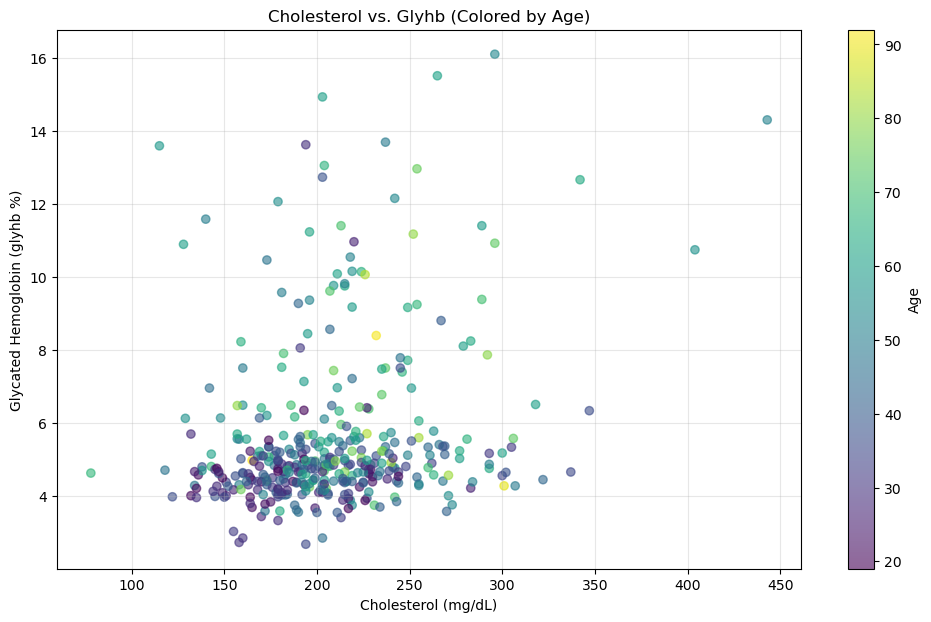

In [65]:
plt.figure(figsize=(12, 7))
plt.scatter(clean_data['chol'], clean_data['glyhb'], c=clean_data['age'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Age')
plt.title('Cholesterol vs. Glyhb (Colored by Age)')
plt.xlabel('Cholesterol (mg/dL)')
plt.ylabel('Glycated Hemoglobin (glyhb %)')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_143/2229938749.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['bmi'] = (clean_data['weight'] / (clean_data['height']**2)) * 703


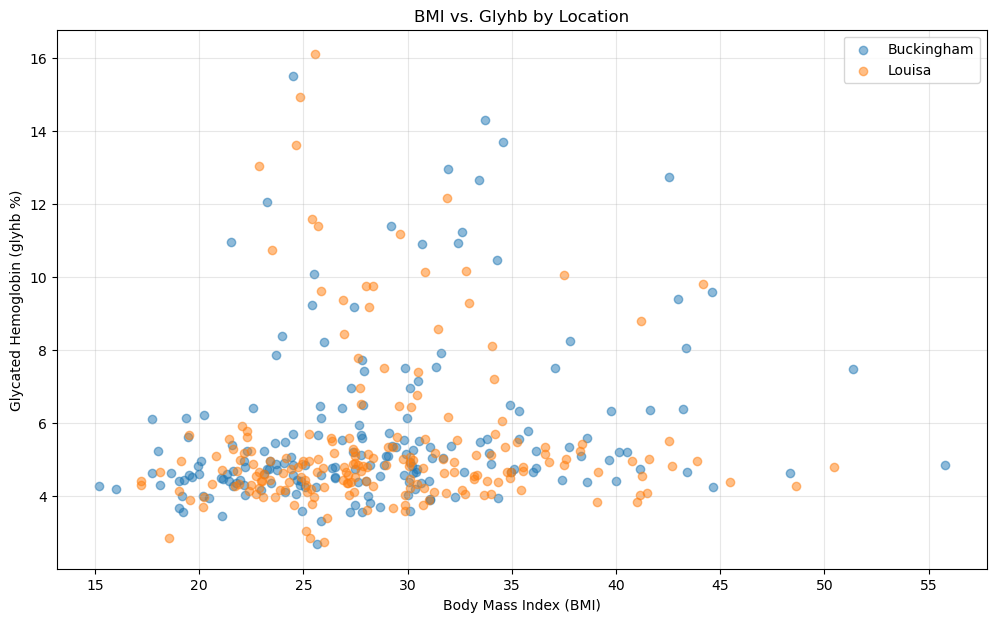

In [66]:
# Calculate BMI (assuming height is in inches and weight in pounds)
clean_data['bmi'] = (clean_data['weight'] / (clean_data['height']**2)) * 703

plt.figure(figsize=(12, 7))
for location in clean_data['location'].unique():
    subset = clean_data[clean_data['location'] == location]
    plt.scatter(subset['bmi'], subset['glyhb'], alpha=0.5, label=location)
    
plt.title('BMI vs. Glyhb by Location')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Glycated Hemoglobin (glyhb %)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()